# 06 - CA And CP Basics: Chrono Experiments

This notebook introduces the packaged chronoamperometry (CA/CPE) and chronopotentiometry (CP) example data. You will load one CA file, load the full CA series, calculate cumulative charge, mark a target charge, load a CP cycling file, summarize cycles, plot selected cycles, and export the processed traces.

The data are included so the notebook renders end-to-end. They are useful examples for learning the workflow, not curated mechanistic benchmarks.

## Import eCAT And Set Paths

Later notebooks use the shorter setup pattern introduced in notebook 02. Change `CA_DIR` or `CP_DIR` when you want to run the same workflow on your own chrono exports.

In [1]:
from pathlib import Path
import sys

import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        return path.name

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import ecat as e

CA_DIR = ROOT / "examples" / "data" / "chrono_ca"
CP_DIR = ROOT / "examples" / "data" / "chrono_cp"
EXPORT_DIR = ROOT / "notebooks" / "_outputs"
EXPORT_DIR.mkdir(exist_ok=True)

e.plotting_style("notebook")
print("eCAT version:", getattr(e, "__version__", "unknown"))
print("CA example files:", len(list(CA_DIR.glob("*.txt"))))
print("CP example files:", len(list(CP_DIR.glob("*.txt"))))

eCAT version: 0.1.0b2
CA example files: 4
CP example files: 1


## `e.echem.from_file()` For One CA Trace

Use `e.echem.from_file()` when you want to inspect a single chronoamperometry or CPE export before loading a whole folder. The CA object stores time/current data plus header values such as the applied potential, run time, and iR compensation information.

In [2]:
ca_file = CA_DIR / "CO2_0.1MKCl_Fe-2imm_-1.0VvsAgAgCl_60min_cpe_1.274C.txt"
ca = e.echem.from_file(str(ca_file), {
    "print": True,
})

,Metric,Value
0,Name,CO2_0.1MKCl_Fe-2imm_-1.0VvsAgAgCl_60min_cpe_1.274C
1,Timestamp,2024-05-04 14:25:04
2,Creation Time,2026-06-09 16:06:55.349225
3,Modification Time,2026-06-09 16:06:55.350078
4,IR Comp Resistance,42.2 ohm
5,IR Uncomp Resistance,0 ohm
6,IR Comp Percent,100 %
7,Gas,CO2
8,Compounds,KCl
9,Concentrations,[0.1 M]


## `.plot()` For Current Versus Time

CA/CPE traces plot current versus time. eCAT automatically chooses readable time and current units for the axis labels.

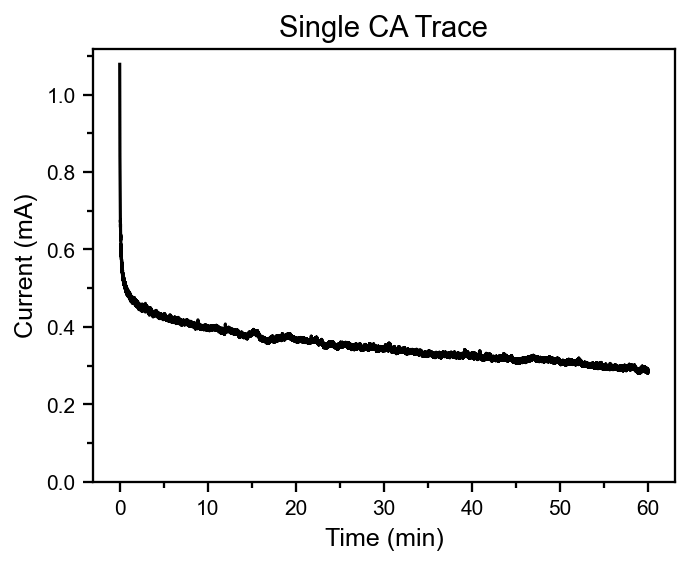

In [3]:
ax = ca.plot({"print": False, "title": "Single CA Trace"})
# ax.figure.savefig(EXPORT_DIR / "ca_single_trace.png", dpi=300, bbox_inches="tight")

## `.charge()` For Cumulative Charge

`ca.charge()` integrates current to cumulative charge in Coulombs. By default it plots charge versus time and returns a dict-like result with the charge trace, final charge, and plotted axes.

Final charge: 1.274 C


1.273778939999998

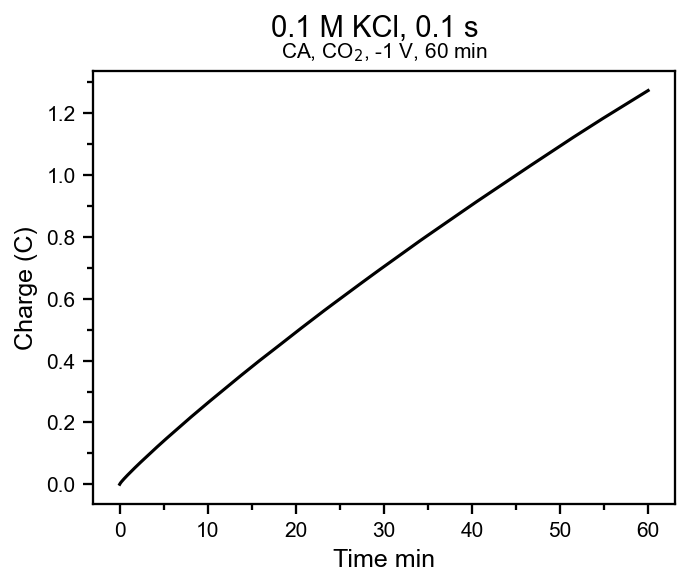

In [4]:
charge_result = ca.charge({"print": True})
charge_result["final charge"]
# charge_result.axes.figure.savefig(EXPORT_DIR / "ca_charge_trace.png", dpi=300, bbox_inches="tight")

## `ca.plot({"plot charge": True})` For A Second-Axis Overlay

Use the `plot charge` option when you want current and cumulative charge on the same CA plot. Current remains on the left axis and charge is drawn on the right axis. Use `charge color` to color the charge line, right-axis label, ticks, and spine together.


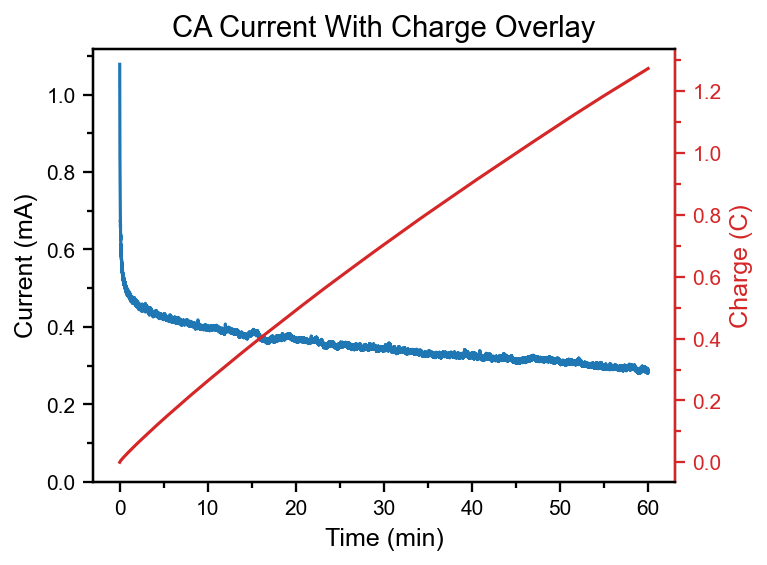

In [5]:
ax = ca.plot({
    "plot charge": True,
    "color": "tab:blue",
    "charge color": "tab:red",
    "title": "CA Current With Charge Overlay",
})
# ax.figure.savefig(EXPORT_DIR / "ca_current_charge_overlay.png", dpi=300, bbox_inches="tight")


## `.charge({"baseline correction": True})` For CA Baseline Cleanup

Baseline correction removes a residual baseline current before integrating charge. With `baseline correction: True`, eCAT uses `baseline threshold` when you provide one; otherwise it estimates the baseline from the final `baseline tail fraction` of the trace, which defaults to 5%.


Final charge: 1.274 C


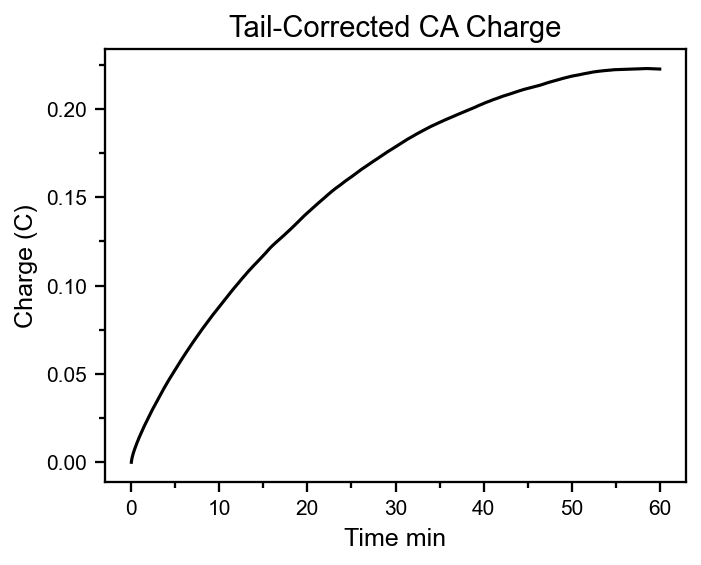

In [6]:
corrected_charge = ca.charge({
    "baseline correction": True,
    "baseline tail fraction": 0.05,
    "plot": True,
    "print": True,
    "title": "Tail-Corrected CA Charge",
})
# corrected_charge.axes.figure.savefig(EXPORT_DIR / "ca_tail_corrected_charge.png", dpi=300, bbox_inches="tight")


## `.time_at_charge()` For A Target Charge

`time_at_charge()` finds when cumulative charge reaches a target. Use `target charge` for Coulombs directly, or use `target moles` with `target electrons` when you want eCAT to calculate the Coulombs from Faraday's constant. The `plot` and `plot ca` options mirror the single-CV analysis style: `plot` adds the diagnostic marker, and `plot ca` includes the CA current trace.

t(0.75 C) = 32.23 min


1933.7884125144842

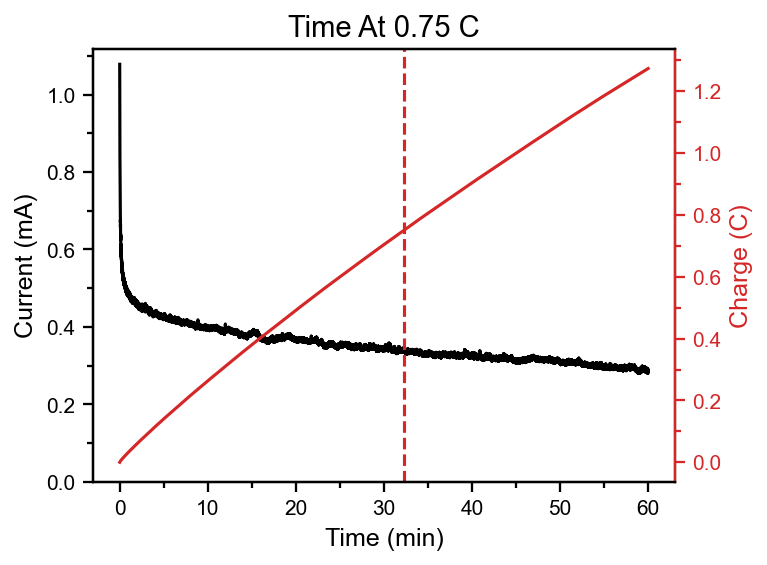

In [7]:
target_result = ca.time_at_charge({
    "target charge": 0.75,
    "plot": True,
    "plot ca": True,
    "print": True,
    "title": "Time At 0.75 C",
})
target_result["time"]
# target_result.axes.figure.savefig(EXPORT_DIR / "ca_time_at_charge.png", dpi=300, bbox_inches="tight")

## `e.get_data()` For A CA Folder

Use `e.get_data()` for a folder of chrono files. `e.show_objects()` gives a quick table of the loaded objects before you calculate a custom series summary.

In [8]:
ca_objects = e.get_data({
    "folder path": str(CA_DIR),
    "reference mode": "none",
    "print": True,
})

Searching recursively through:
 examples/data/chrono_ca
4 .txt files found.

[Conditions] Exp Type: CA, Gas: CO₂, Compounds: 0.1 M KCl, Technique: CA, IR Comp Percent: 100 %, Run Time: 60 min, Sample Interval: 0.1 s


,Applied Potential
[0],-1 V
[1],-1.1 V
[2],-1.2 V
[3],-0.95 V


In [9]:
e.show_objects(ca_objects, {
    "columns": [
        "name",
        "type",
        "Init Potential",
        "Run Time",
        "ir comp resistance",
    ],
})

[Conditions] Exp Type: CA, Gas: CO₂, Compounds: 0.1 M KCl, Technique: CA, IR Comp Percent: 100 %, Run Time: 60 min, Sample Interval: 0.1 s


,Name,IR Comp Resistance,Applied Potential,Run Time,Type
[0],CO2_0.1MKCl_Fe-2imm_-1.0VvsAgAgCl_60min_cpe_1.274C,42.2,-1 V,60 min,Chronoamperometry
[1],CO2_0.1MKCl_Fe-2imm_-1.1VvsAgAgCl_60min_cpe_2.192C,47.8,-1.1 V,60 min,Chronoamperometry
[2],CO2_0.1MKCl_Fe-2imm_-1.2VvsAgAgCl_60min_cpe_2.565C,40,-1.2 V,60 min,Chronoamperometry
[3],CO2_0.1MKCl_Fe-2imm_-0.95VvsAgAgCl_60min_cpe_0.6516C,57,-0.95 V,60 min,Chronoamperometry


## Charge Summary Across The CA Series

After confirming the objects loaded correctly, build a compact table from the public object attributes and `charge({"plot": False})` results.

In [10]:
charge_summary = pd.DataFrame([
    {
        "Applied potential (V)": obj.init_E,
        "Run time (min)": obj.run_time / 60 if obj.run_time is not None else None,
        "Final charge (C)": obj.charge({"plot": False, "print": False})["final charge"],
    }
    for obj in ca_objects
]).sort_values("Applied potential (V)", ascending=False)

charge_summary

,Applied potential (V),Run time (min),Final charge (C)
3,-0.95,60.0,0.651626
0,-1.00,60.0,1.273779
1,-1.10,60.0,2.192180
2,-1.20,60.0,2.565288


## `e.echem.from_file()` For One CP Cycling File

Chronopotentiometry data store time/potential traces and current-step metadata. The packaged CP file is a cycling experiment, so it can also be summarized cycle-by-cycle.

In [11]:
cp_file = next(CP_DIR.glob("*.txt"))
cp = e.echem.from_file(str(cp_file), {
    "reference mode": "none",
    "print": True,
})

,Metric,Value
0,Name,CP-100-cycles_MeCN_500mVs_100mMTBAPF6_gcWE_ptCE_AgAgbf4-5mM
1,Timestamp,2022-01-27 13:43:22
2,Creation Time,2026-06-09 16:06:55.405941
3,Modification Time,2026-06-09 16:06:55.411203
4,Solvent,MeCN
5,Compounds,TBAPF6
6,Concentrations,[100 mM]
7,Cathodic Current,5 mA
8,Anodic Current,5 mA
9,Initial P/n,N


## `.plot()` For Potential Versus Time

The basic CP plot shows potential over the full experiment time.

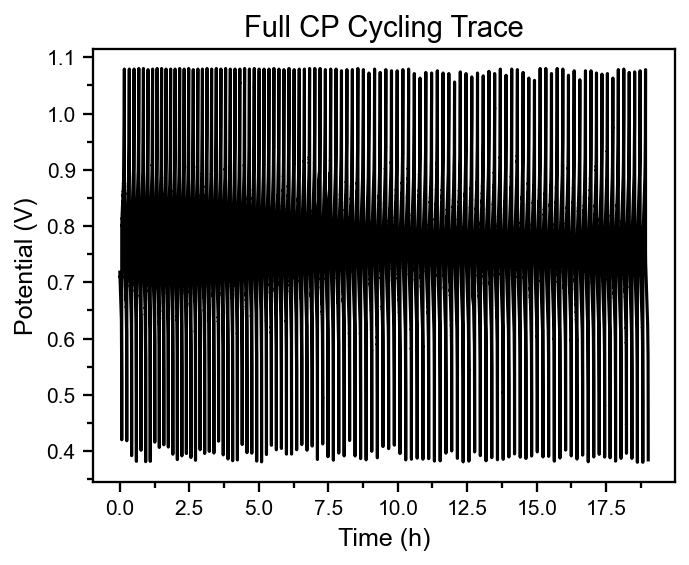

In [12]:
ax = cp.plot({"print": False, "title": "Full CP Cycling Trace"})
# ax.figure.savefig(EXPORT_DIR / "cp_full_trace.png", dpi=300, bbox_inches="tight")

## `.cycling_plot()` For CP Performance Overlays

Use `cycling_plot()` when you want cycle-by-cycle performance metrics such as capacity and efficiency overlaid against cycle number. This is different from `plot_cycles()`, which overlays the selected potential traces themselves.


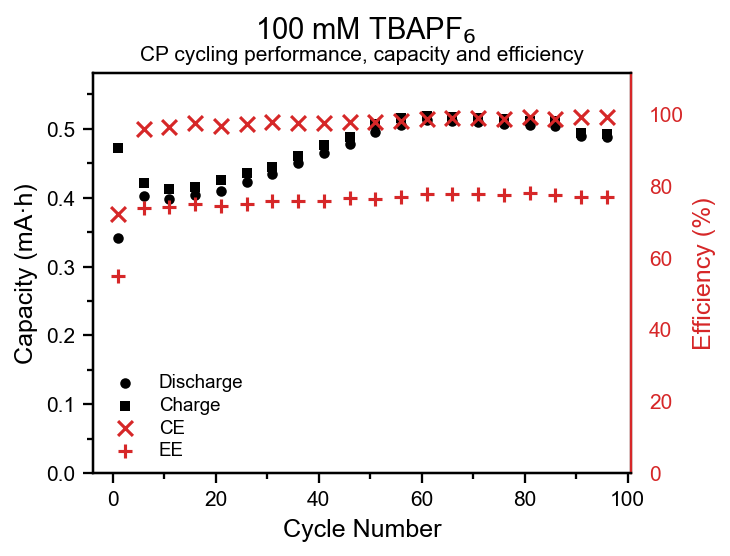

In [13]:
fig, (ax_capacity, ax_efficiency) = cp.cycling_plot({
    "cycles": (1, 100, 5),
    "percent capacity": False,
    "capacity mode": "both",
    "efficiency mode": "both",
    "legend": True,
})
# fig.savefig(EXPORT_DIR / "cp_cycling_performance.png", dpi=300, bbox_inches="tight")


## `.cycle_info()` For CP Cycle Summaries

`cycle_info()` estimates charge/discharge capacities, efficiencies, energies, and end-of-step potentials for each detected cycle. Start by inspecting the first few rows before using the whole table downstream.

In [14]:
cycle_info = cp.cycle_info({"percent capacity": False})
cycle_info.head()
# cycle_info.to_csv(EXPORT_DIR / "cp_cycle_info.csv", index=False)

,Cycle,Duration (s),Discharge Capacity (mA·h),Charge Capacity (mA·h),Coulombic Efficiency (%),Discharge Energy (mWh),Charge Energy (mWh),Energy Efficiency (%),Discharge Potential (V),Charge Potential (V)
0,1,586.0,0.340972,0.472917,72.099853,0.226581,0.412299,54.955489,0.4201,1.078
1,2,637.0,0.430556,0.454167,94.801223,0.291830,0.396646,73.574546,0.4184,1.079
2,3,620.5,0.420139,0.441667,95.125786,0.284567,0.386162,73.691106,0.3919,1.079
3,4,610.0,0.413889,0.433333,95.512821,0.279739,0.379141,73.782359,0.3818,1.080
4,5,598.0,0.406250,0.424306,95.744681,0.275015,0.371480,74.032234,0.4014,1.080


## `.plot_cycles()` For Selected CP Cycles

Use `plot_cycles()` to compare selected cycles. The `(start, end, step)` tuple below plots every twentieth cycle from cycle 1 through cycle 100, with charge and discharge segments labeled separately. The same gradient and colorbar options used by `multiplot()` can color the selected cycles by cycle number.


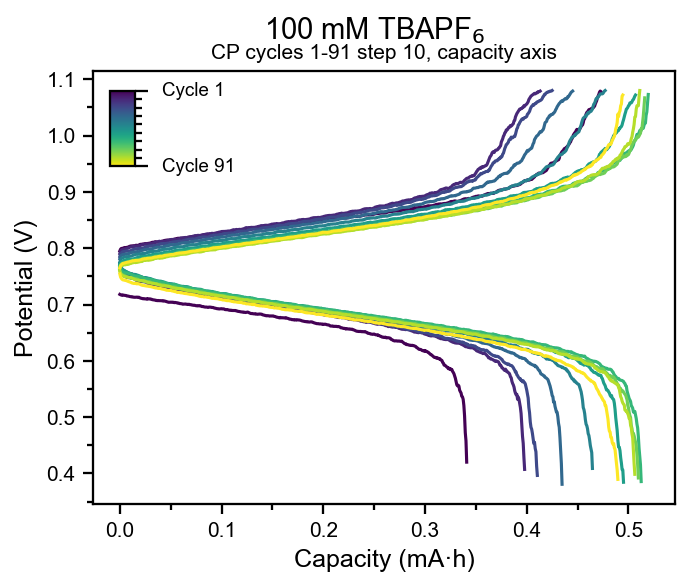

In [15]:
ax = cp.plot_cycles({
    "cycles": (1, 100, 10),
    "segment": "both",
    "x axis": "capacity",
    "color mode": "gradient",
    "gradient colormap": "viridis",
    'legend': True,
    "legend mode": "colorbar",
})
# ax.figure.savefig(EXPORT_DIR / "cp_selected_cycles.png", dpi=300, bbox_inches="tight")


## Export CA And CP Data With `save_data`

`save_data()` can export a mixed list of loaded eCAT objects. The returned DataFrame is also useful for checking the export shape before opening the CSV elsewhere.

In [16]:
exported = e.save_data(ca_objects + [cp], {
    "folder path": str(EXPORT_DIR),
    "file name": "ca_cp_quickstart_export",
})
exported.head()

Saved 5 echem objects to:
notebooks/_outputs/ca_cp_quickstart_export.csv


CO2_0.1MKCl_Fe-2imm_-1.0VvsAgAgCl_60min_cpe_1.274C              \
                                            Time (s) Current (A)   
0                                                0.1    0.001078   
1                                                0.2    0.001048   
2                                                0.3    0.001023   
3                                                0.4    0.001009   
4                                                0.5    0.000999   

  CO2_0.1MKCl_Fe-2imm_-1.1VvsAgAgCl_60min_cpe_2.192C              \
                                            Time (s) Current (A)   
0                                                0.1    0.001851   
1                                                0.2    0.001835   
2                                                0.3    0.001815   
3                                                0.4    0.001788   
4                                                0.5    0.001771   

  CO2_0.1MKCl_Fe-2imm_-1.2VvsAgAgCl_60min_cpe_2.565C              \
                                            Time (s) Current (A)   
0                                                0.1    0.002851   
1                                                0.2    0.002826   
2                                                0.3    0.002792   
3                                                0.4    0.002760   
4                                                0.5    0.002731   

  CO2_0.1MKCl_Fe-2imm_-0.95VvsAgAgCl_60min_cpe_0.6516C              \
                                              Time (s) Current (A)   
0                                                0.1      0.000763   
1                                                0.2      0.000747   
2                                                0.3      0.000746   
3                                                0.4      0.000720   
4                                                0.5      0.000678   

  CP-100-cycles_MeCN_500mVs_100mMTBAPF6_gcWE_ptCE_AgAgbf4-5mM                
                                                     Time (s) Potential (V)  
0                                                0.5                 0.7180  
1                                                1.0                 0.7173  
2                                                1.5                 0.7169  
3                                                2.0                 0.7164  
4                                                2.5                 0.7171